In [1]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *
from utils.Phase_diversity_helpers_cupy import *

Failed to import cupy.


In [3]:
#minor style things to make the figures look nice
#plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 15
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [4]:
N_order = 3              # 3 for 3P, 2 for 2P
lambd = 1.3e-3            # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05            # Numerical aperture
focal = 7.2                    # Focal length of objective (Olympus) [mm]
mag = 4                   # Magnification rate from input to objective
w_0 = 3.5                 # mm
alpha = np.arcsin(num_apt / n)

#25 microns
L_ffp = 0.025
#512 x 512
grid_ffp = 128
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
#CONJUGATE BFP LENGTH
grid_bfp = grid_ffp
L_bfp = (lambd * focal * grid_bfp) / L_ffp
microscope = Microscope(N_order, lambd, n, num_apt, focal, mag, w_0, L_bfp, grid_bfp)
x, y = grid.get_xy()
x_bfp = x * (L_bfp/ L_ffp)
y_bfp = y * (L_bfp/ L_ffp)

In [5]:
import numpy as np

def bin_256_to_128(img, mode="sum"):

    binned = img.reshape(128, 2, 128, 2)

    if mode == "sum":
        return binned.sum(axis=(1, 3))
    elif mode == "mean":
        return binned.mean(axis=(1, 3))


In [6]:
from PIL import Image
f = np.asarray(Image.open("images/aerial.tiff"))

f = (f - np.min(f))/ (np.max(f) - np.min(f))

In [ ]:
rng = np.random.default_rng(15)
true_aberration = generate_johnson_aberration(0.5, alpha)
SNR = 20
bias_modes = get_johnson_modes()
bias_strength = 1.5
a_stack = [EmptyAberration()] + [Aberration([m], [bias_strength]) for m in bias_modes]
img_stack = np.array([get_diversity_image(microscope, bin_256_to_128(f), true_aberration, a, gaussian = True) for a in a_stack])
d_stack = [add_gaussian_noise(img, SNR, rng) for img in img_stack]


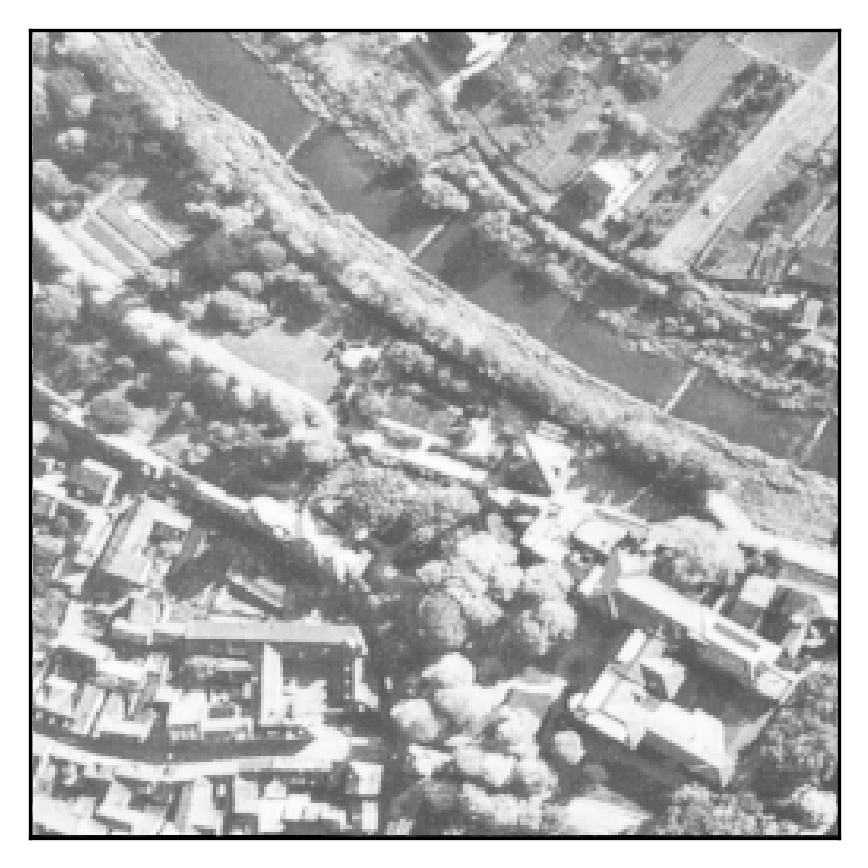

In [23]:
plot_intensity_clean(x, y, np.flip(f, axis = 0))

In [24]:
gamma = 1e-24

params = {
                "gamma": gamma,
                "J_tol": 0.001,
                "max_step": 0.05
            }

modes_corrected = get_johnson_modes()


c_guess, F_guess, c_guess_log, F_guess_log, J_log = loop_optimize(n_loops = 200,
                                microscope = microscope,
                                d_stack = d_stack,
                                a_stack = a_stack,
                                modes_corrected = modes_corrected,
                                params = params,
                                debug = False,
                                log = True,
                                gaussian = True)

 36%|███▋      | 73/200 [03:05<05:22,  2.54s/it]


KeyboardInterrupt: 

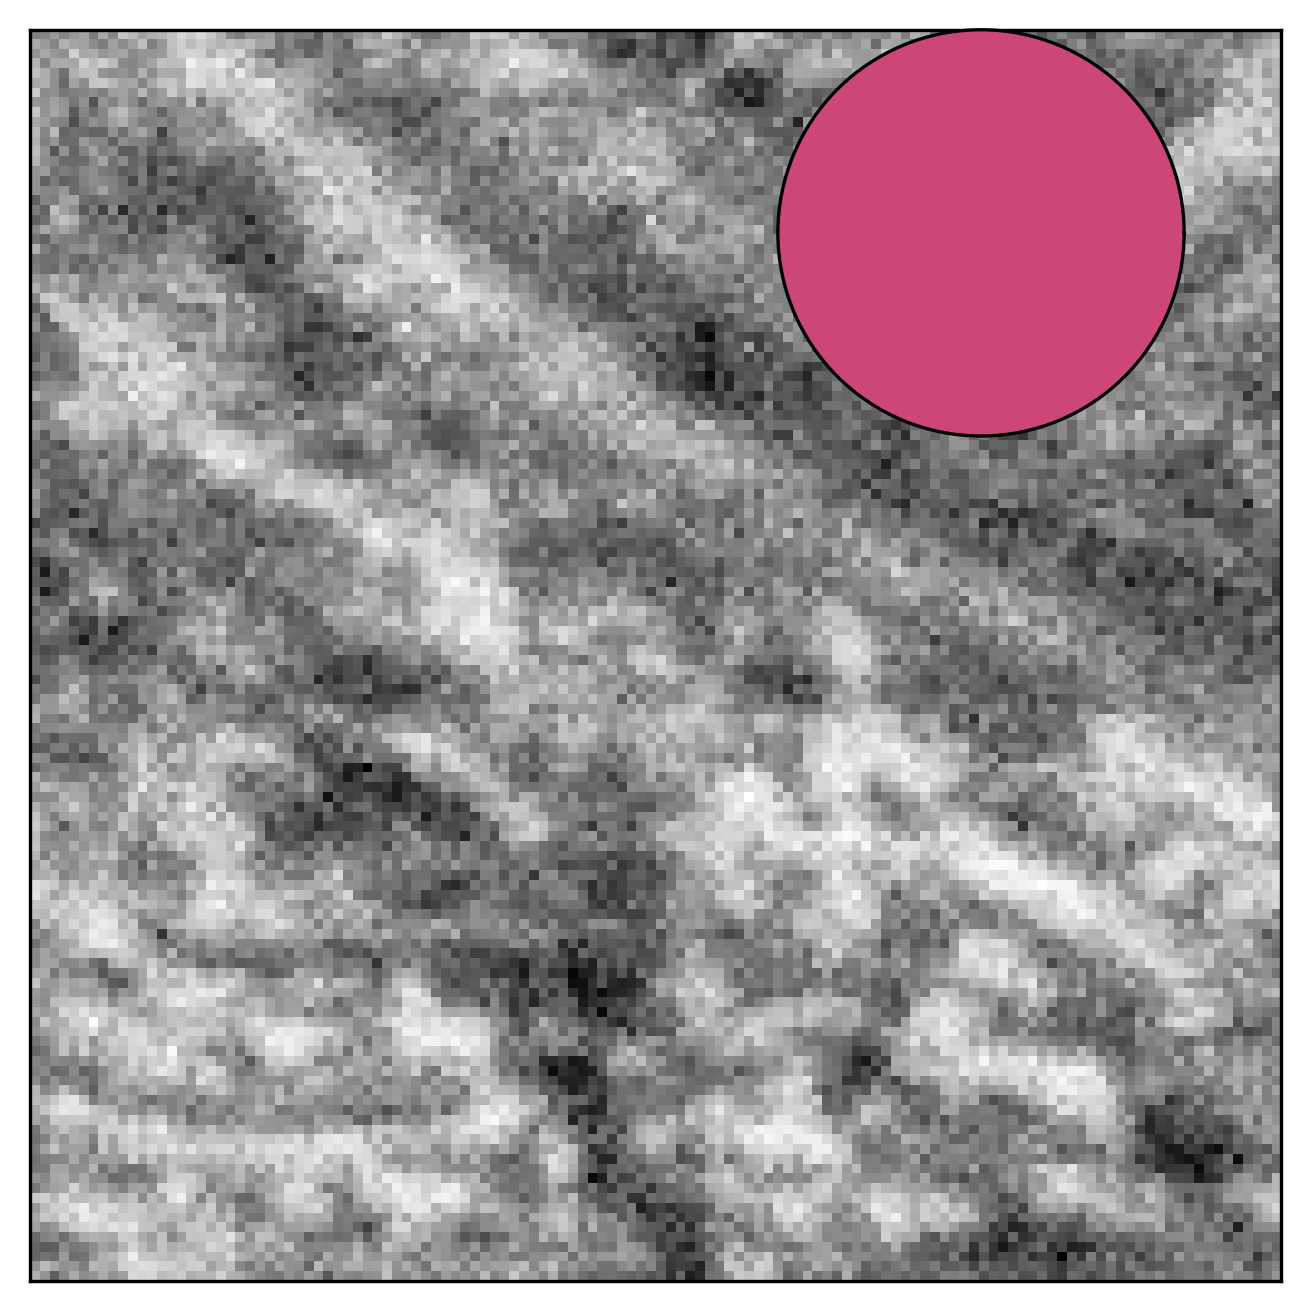

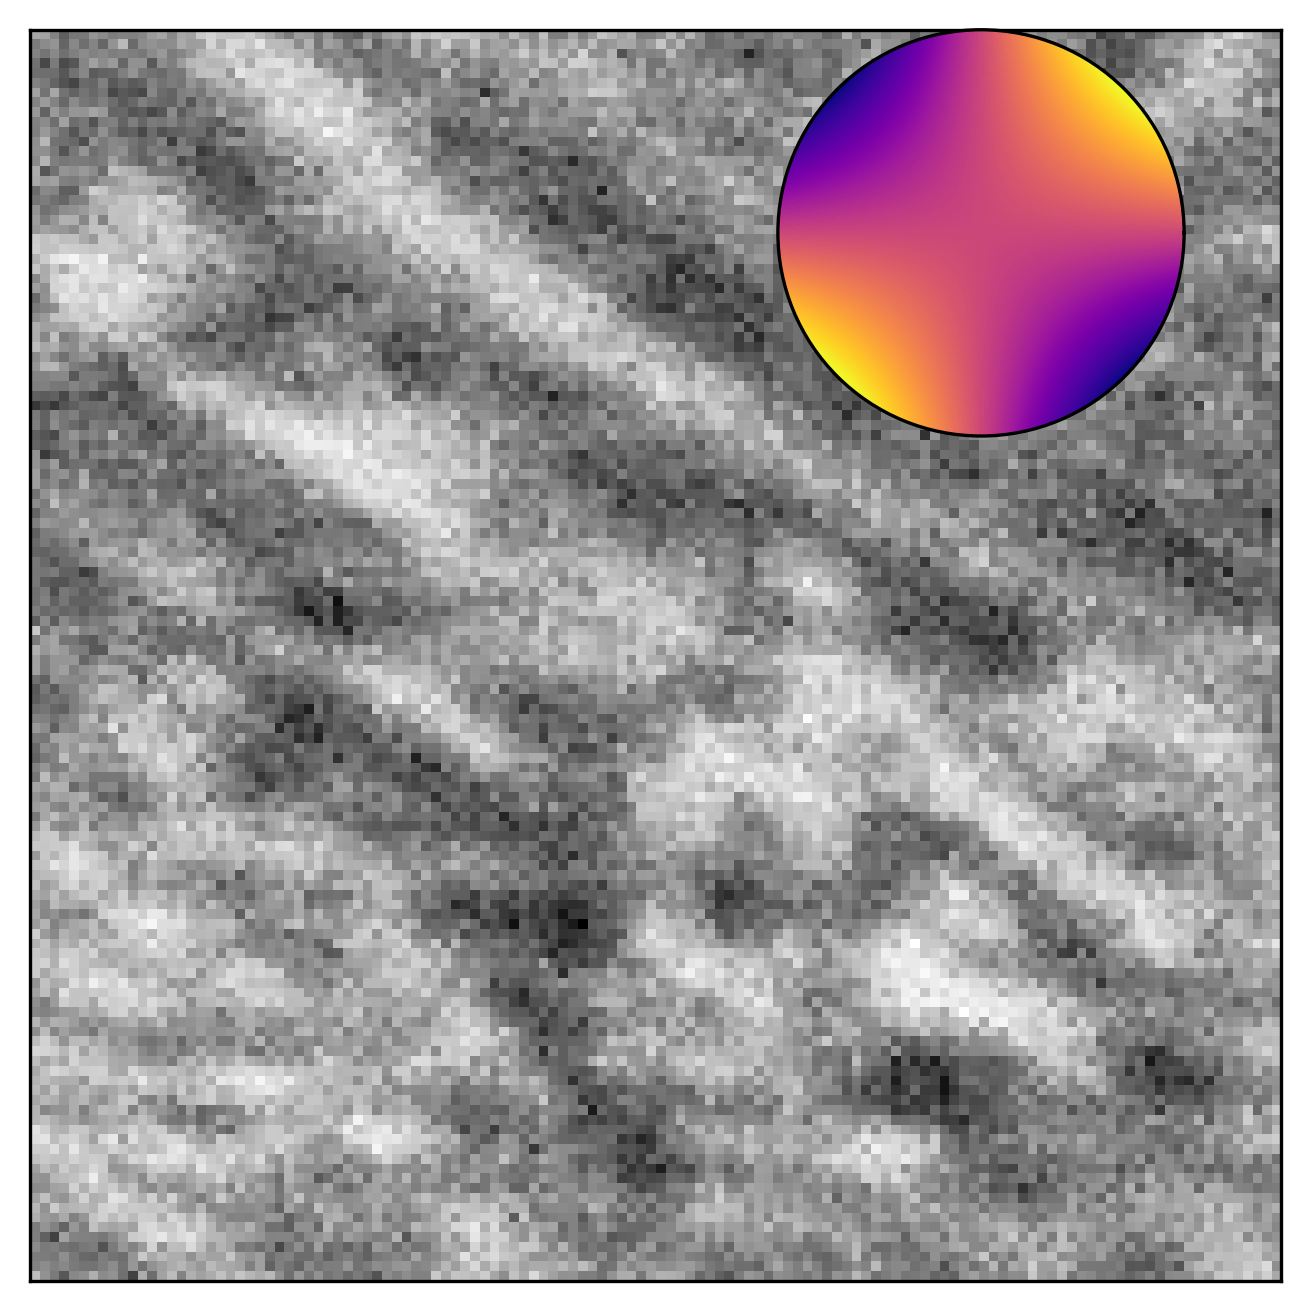

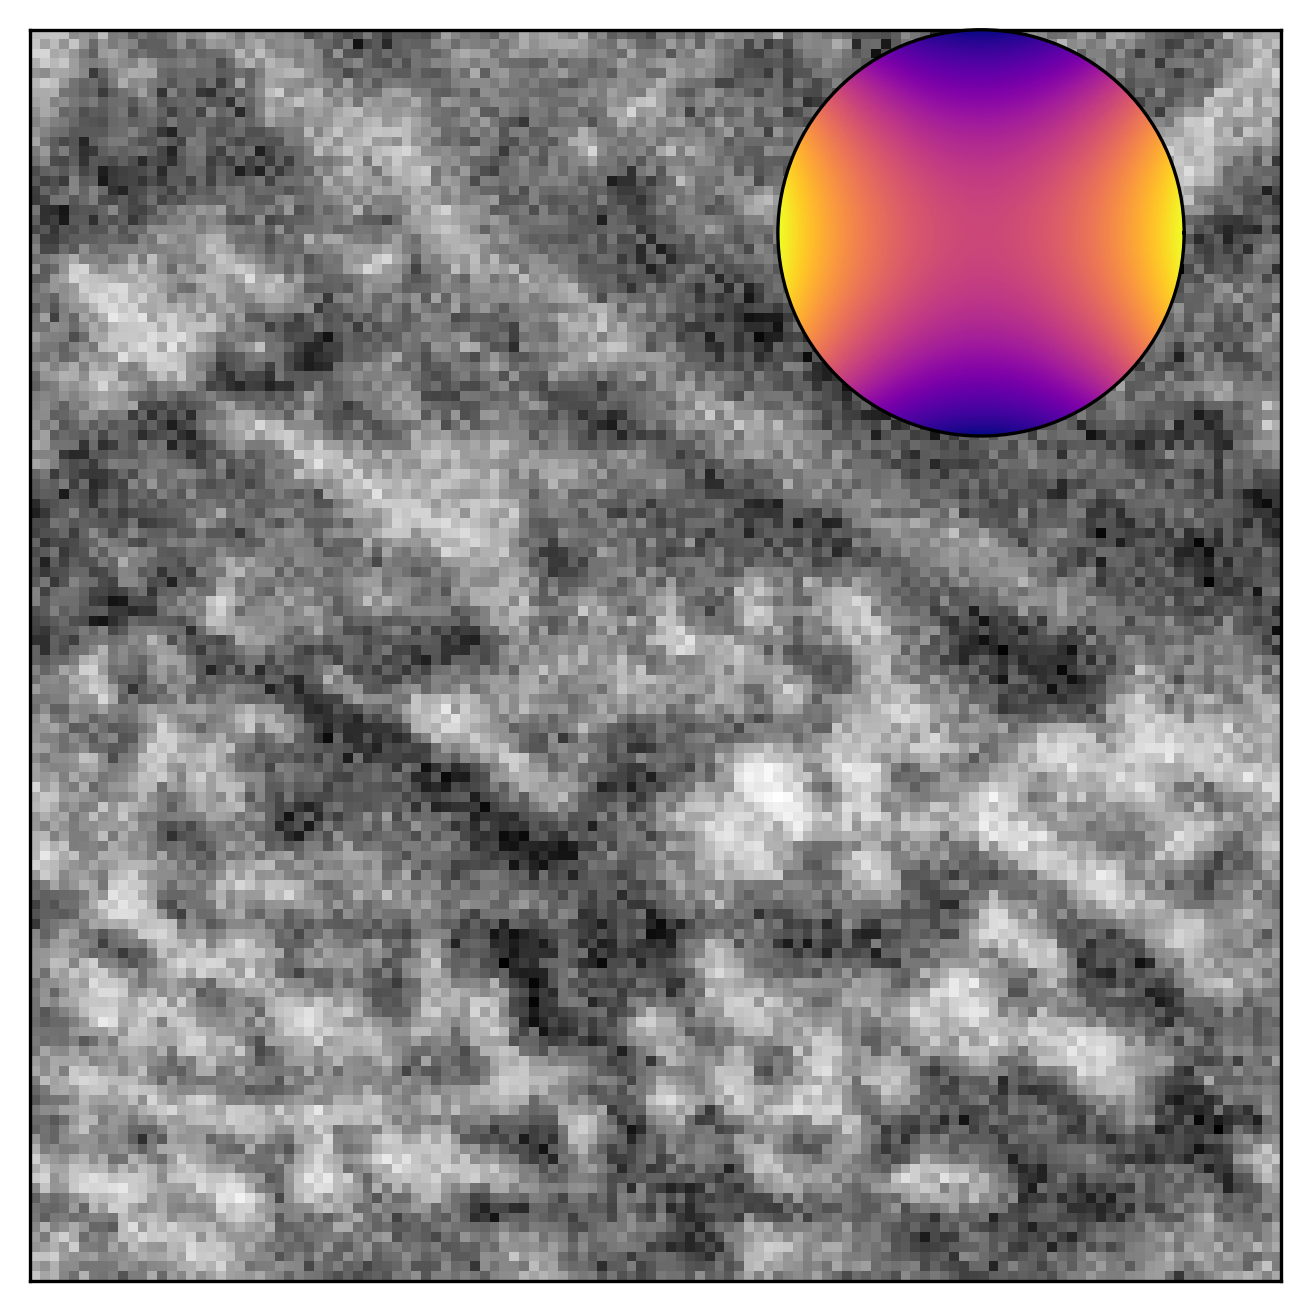

In [10]:
for i in [0,1,2]:
    composite_plot_clean(x, y, np.flip(d_stack[i], axis = 0), a_stack[i].construct_map(alpha), alpha)

In [25]:
max_index = 200
try:
    max_index = np.where(J_log <= 0)[0][0]
except:
    pass
rms_vals = np.zeros(max_index)
for i in range(max_index):
    diff = Aberration(modes_corrected, c_guess_log[i]) - true_aberration
    rms_vals[i] = zernike_RMS(diff, alpha)


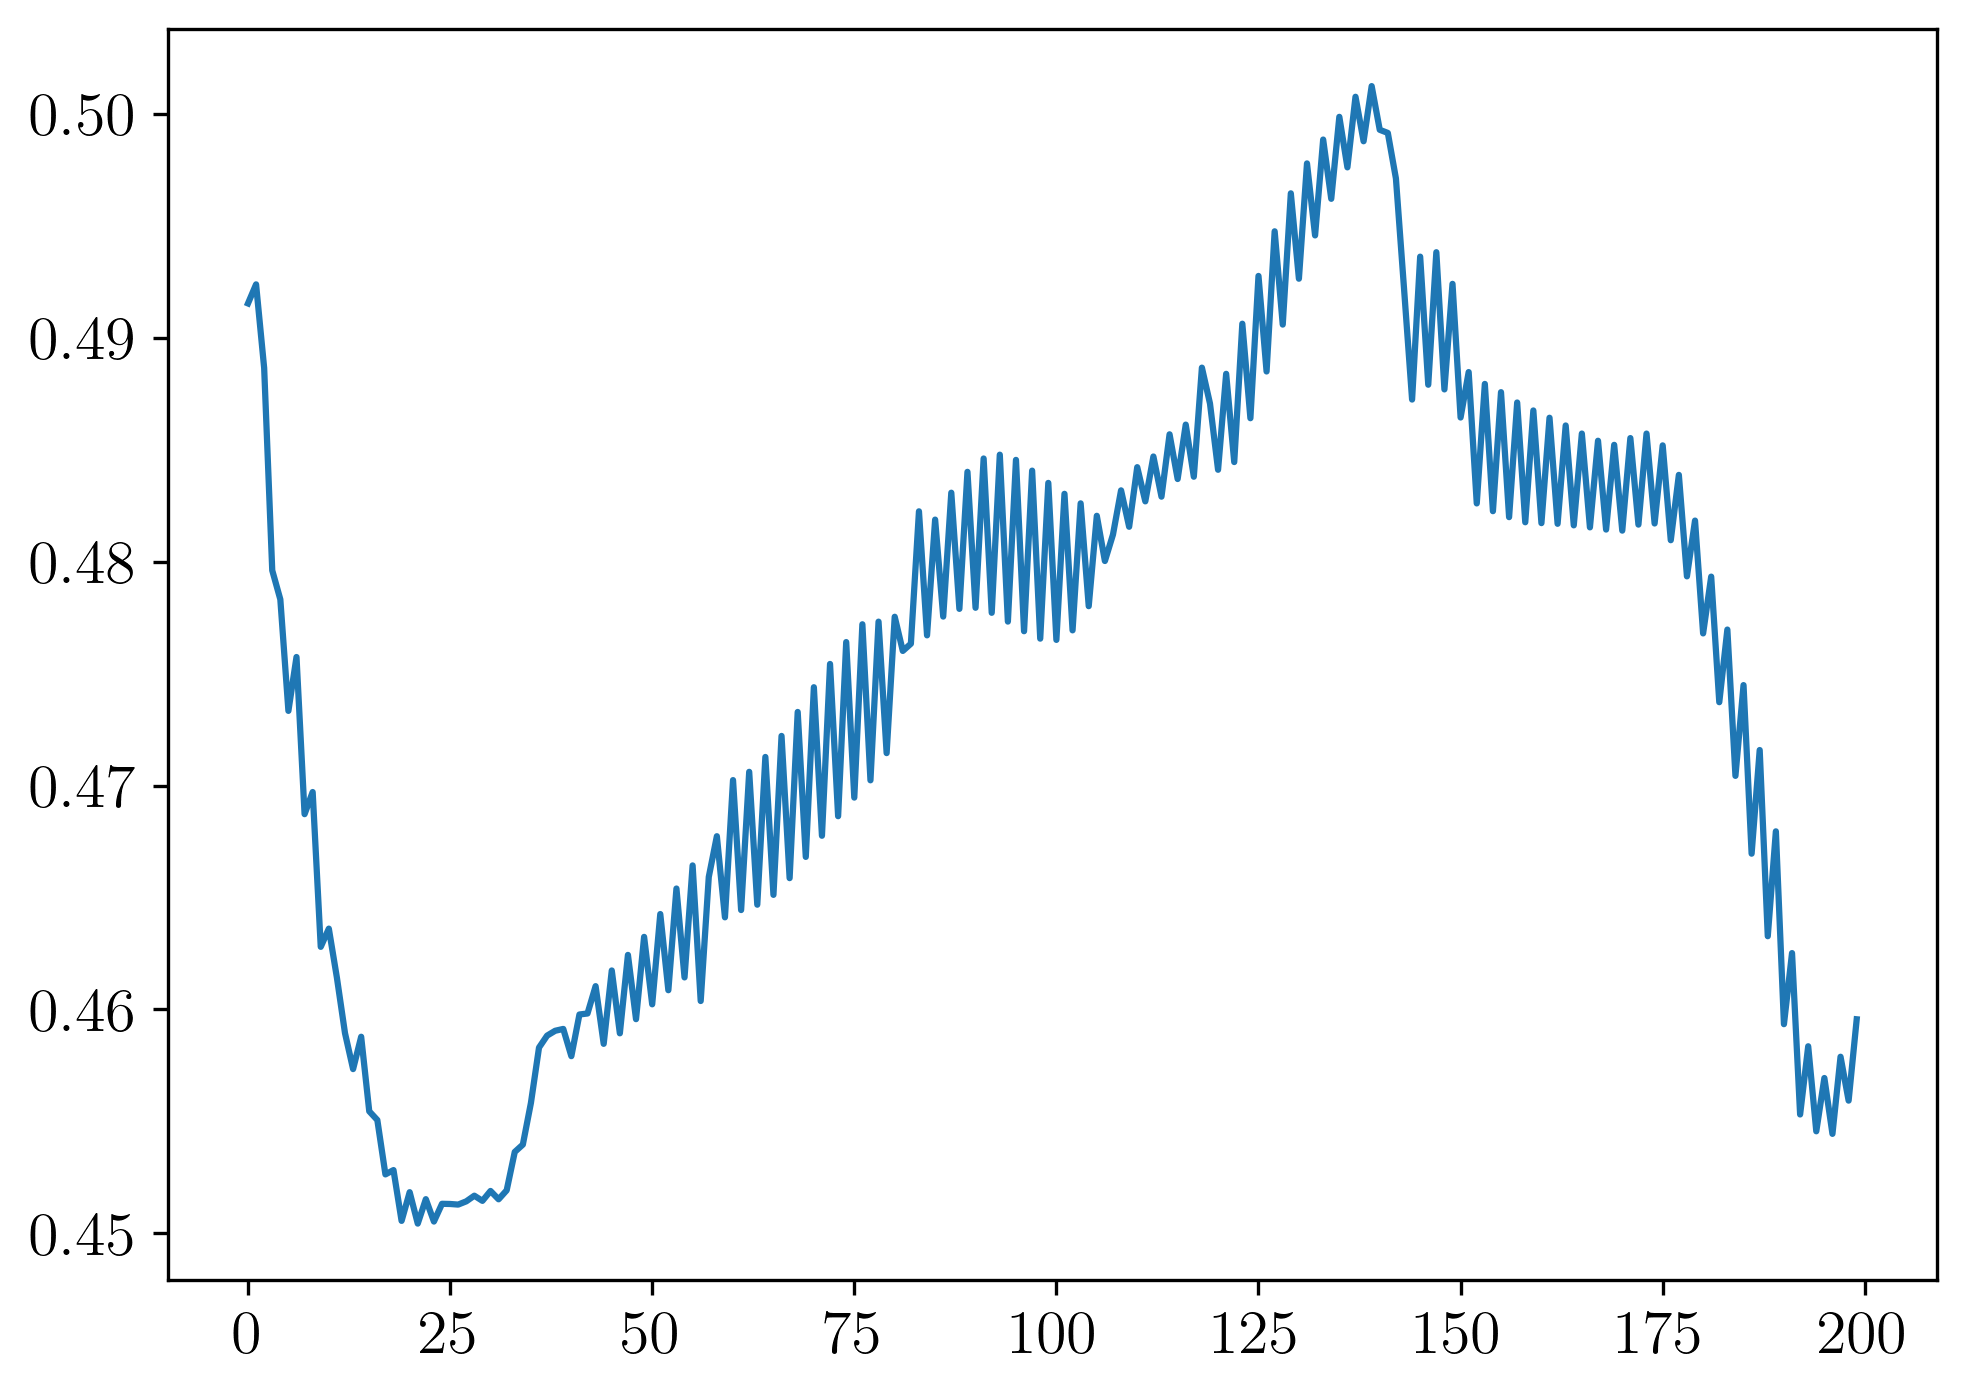

In [26]:
plt.plot(rms_vals)

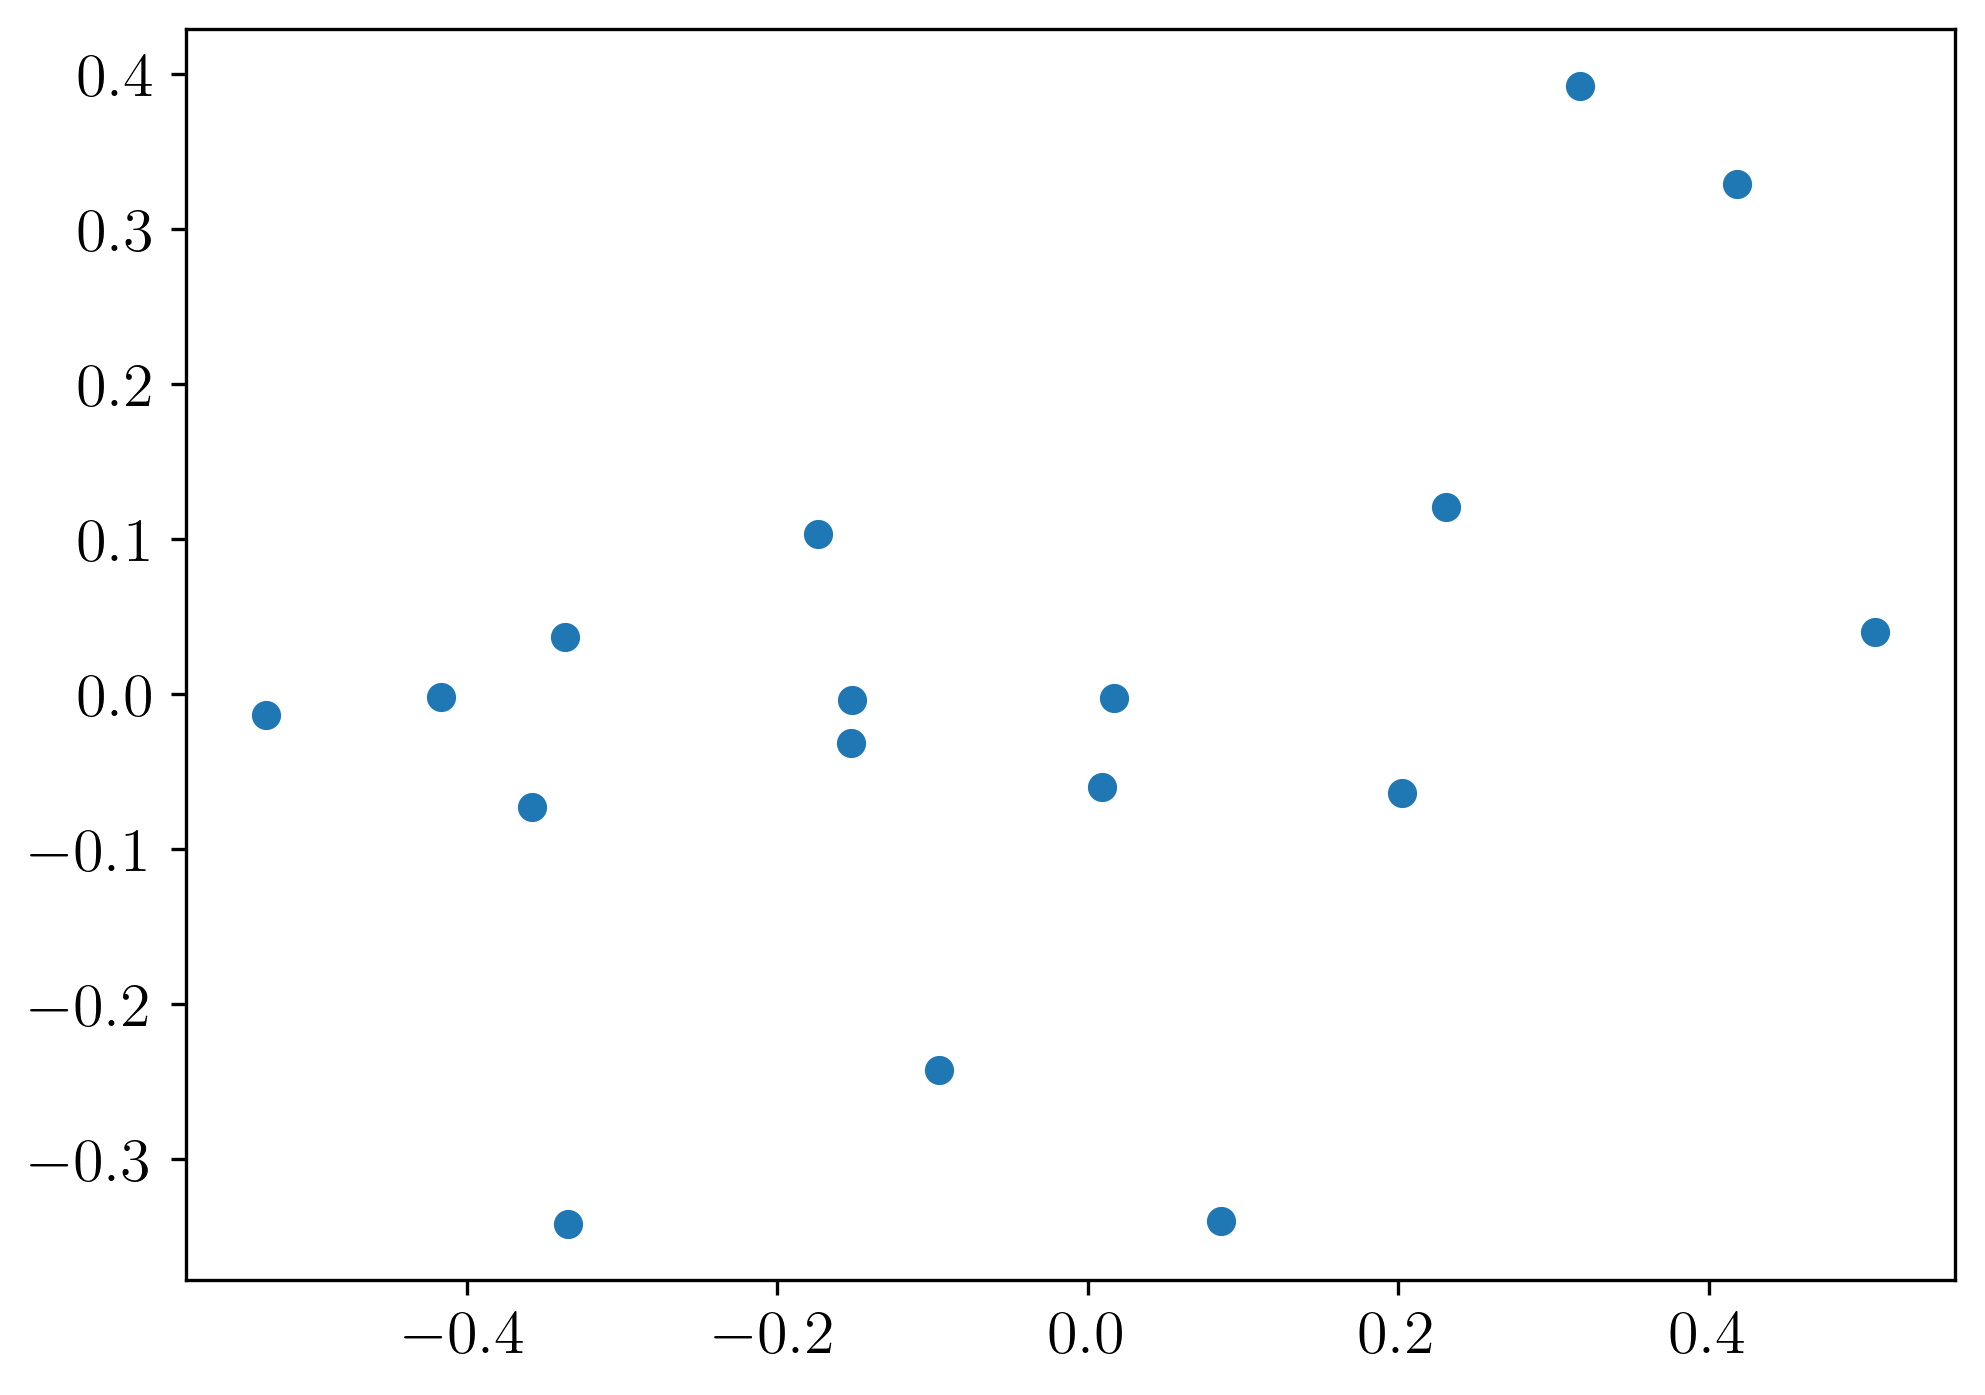

In [27]:
plt.scatter(true_aberration.strengths, c_guess)

In [251]:
def demo_plot(index):
    fig, axs = plt.subplots(
    2, 1,
    dpi=300,
    figsize=(4, 6),
    gridspec_kw={"height_ratios": [2, 1]}
    )

    # -------------------------
    # Top panel: circular aberration map
    # -------------------------
    res = 500

    rho = np.linspace(0, 1, res)
    phi = np.linspace(0, 2*np.pi, res)

    rho_grid, phi_grid = np.meshgrid(rho, phi, indexing="ij")

    x_grid = rho_grid * np.cos(phi_grid)
    y_grid = rho_grid * np.sin(phi_grid)

    theta_grid = np.arcsin(rho_grid * np.sin(alpha))

    aberration = Aberration(modes_corrected, c_guess_log[index])
    z_map = aberration.construct_map(alpha)
    z = z_map(theta_grid, phi_grid)

    pcm = axs[0].pcolormesh(
        x_grid,
        y_grid,
        z,
        shading="auto",
        vmin=-np.pi,
        vmax=np.pi,
        cmap="plasma"
    )

    axs[0].set_aspect("equal")
    axs[0].set_xlim(-1, 1)
    axs[0].set_ylim(-1, 1)
    axs[0].set_xticks([])
    axs[0].set_yticks([])
    axs[0].set_title(f"Iteration {index}")

    # Optional: draw pupil boundary
    circle = plt.Circle((0, 0), 1, fill=False, color="black", linewidth=0)
    axs[0].add_patch(circle)



    # -------------------------
    # Bottom panel: RMS trace
    # -------------------------
    axs[1].plot(rms_vals, marker="x")
    axs[1].set_xlabel("Iteration Number")
    axs[1].set_ylabel("Residual RMS [wv]")

    axs[1].scatter(
        index,
        rms_vals[index],
        color="red",
        s=40,
        zorder=5,
        label=f"Iteration {index}"
    )
    axs[1].set_yticks([0, 0.5, 1, 1.5, 2])

    for spine in axs[0].spines.values():
        spine.set_visible(False)

    fig.tight_layout()
    plt.savefig(f"demo_plots/{index}.png")
    plt.close()


In [252]:
for i in tqdm(range(max_index)):
    demo_plot(i)

  0%|          | 0/42 [00:00<?, ?it/s]

/var/folders/v9/czyc2p85057bkq0_b7k6tp2r0000gn/T/ipykernel_52817/2646041242.py:28: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = axs[0].pcolormesh(
100%|██████████| 42/42 [00:22<00:00,  1.88it/s]


In [253]:
from PIL import Image
import glob

frames = []
imgs = np.array(sorted(glob.glob(f"demo_plots/*.png")))
indices = np.array([int(img.split("/")[1].split(".")[0]) for img in imgs])
imgs = imgs[np.argsort(indices)]

for i in imgs:
    new_frame = Image.open(i)
    frames.append(new_frame)
frames[0].save(f"demo_plots/demo.gif", format='GIF',
            append_images=frames[0:],
            save_all=True,
            duration=150, loop=0)

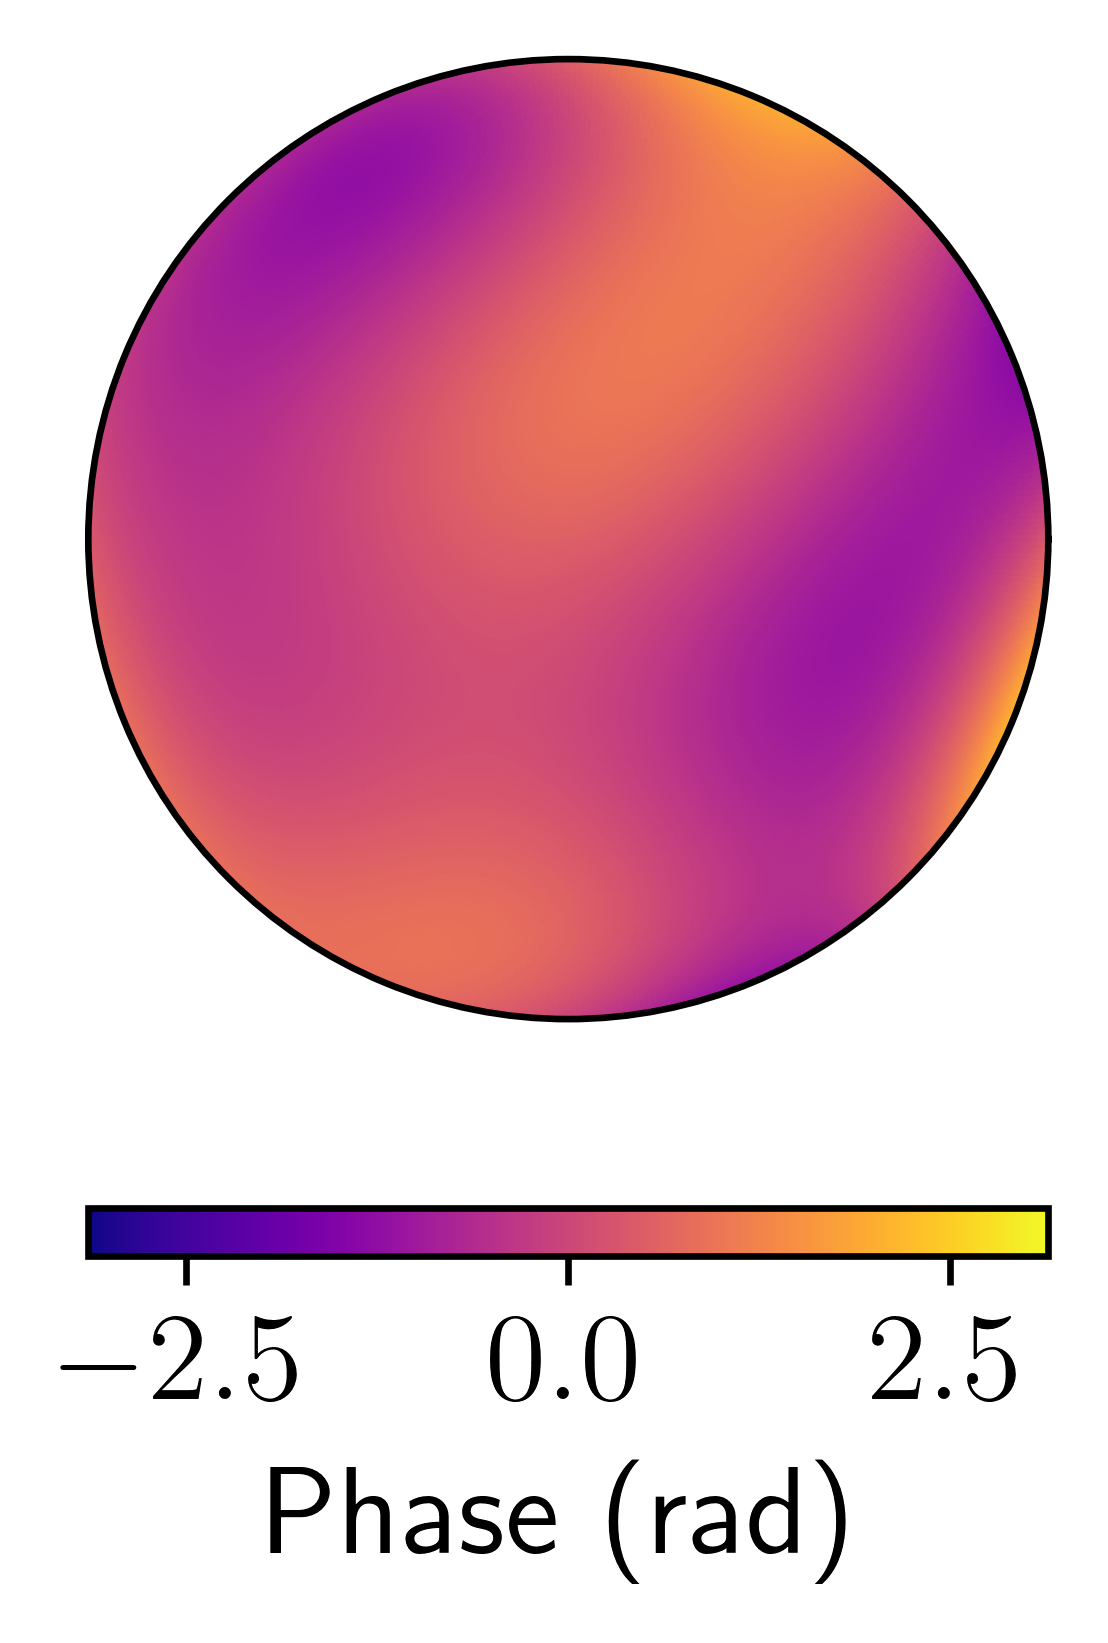

In [255]:
zernike_plot(true_aberration.construct_map(alpha), alpha)

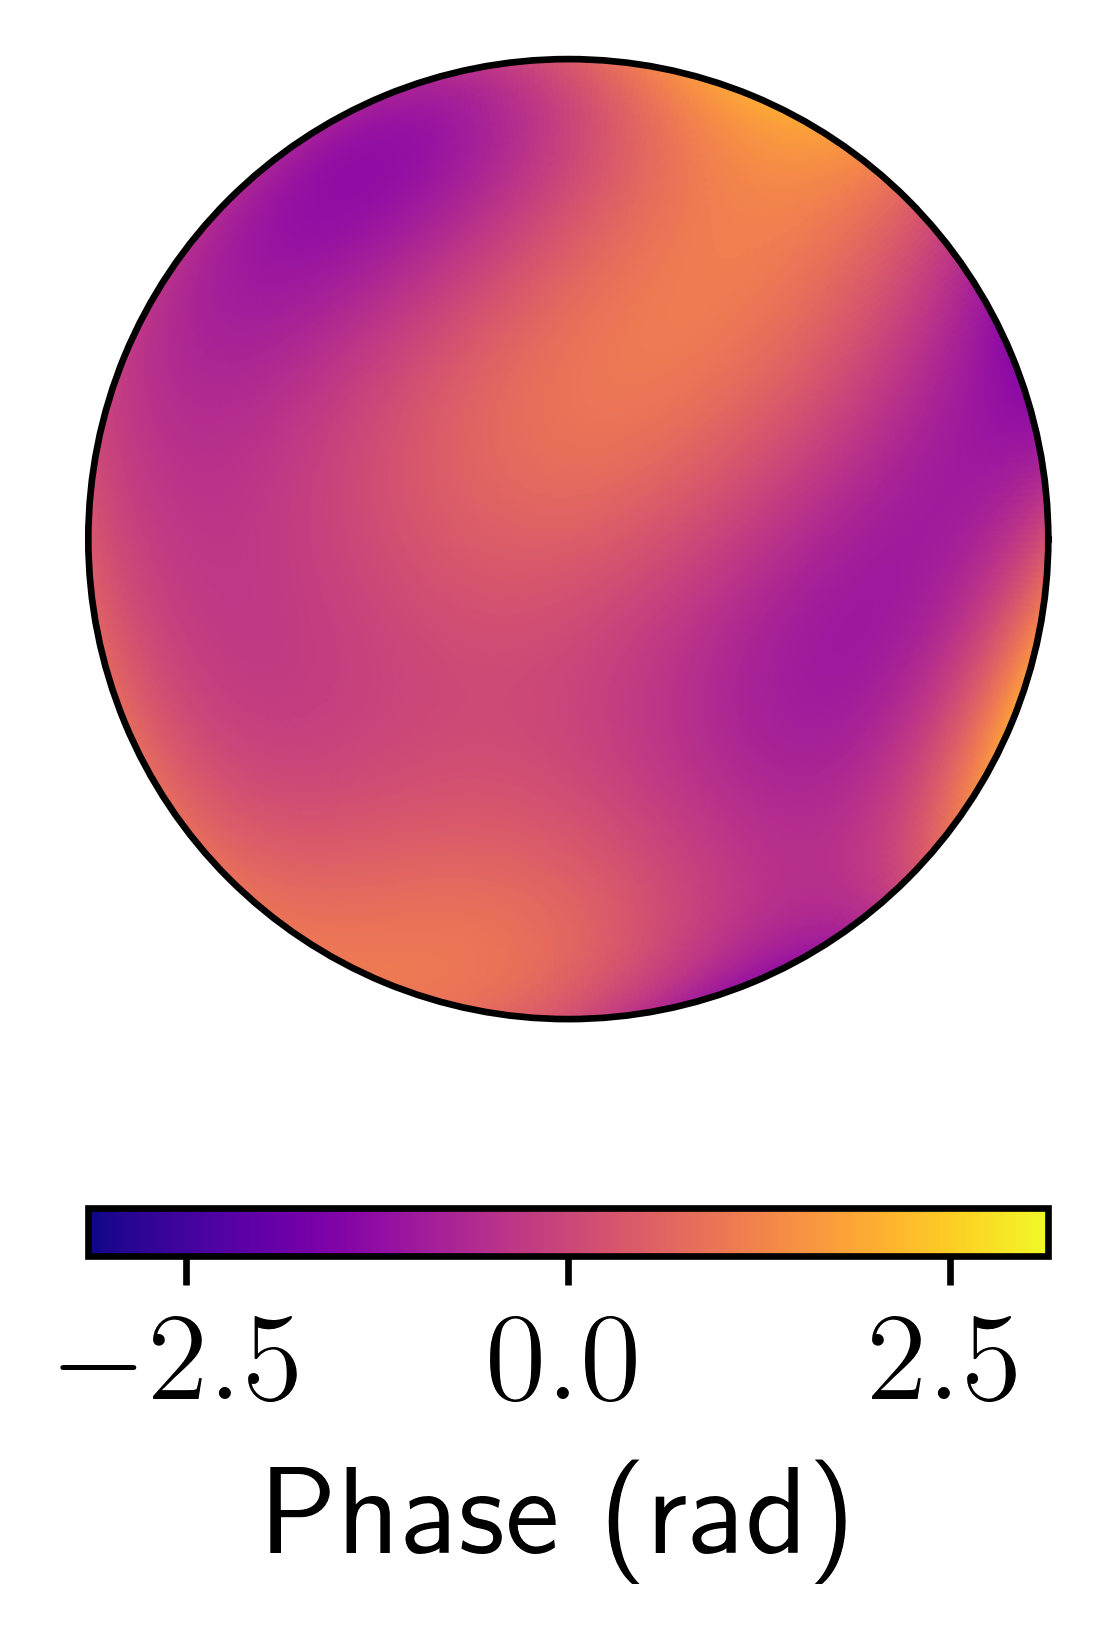

In [256]:
zernike_plot(Aberration(modes_corrected, c_guess).construct_map(alpha), alpha)